# YOLOv3 (darknet) - Windows

원본 [pjreddie/darknet](https://github.com/pjreddie/darknet)은 Unix용 `Makefile`(gcc)로만 빌드되어 Windows에서 그대로 빌드되지 않습니다.
이 노트북은 Windows 빌드를 공식 지원하는 [AlexeyAB/darknet](https://github.com/AlexeyAB/darknet) 포크로 대체합니다.

**사전 준비물 (한 번만 설치)**
- Git for Windows
- CMake (3.18 이상)
- Visual Studio 2019 이상의 "C++를 사용한 데스크톱 개발" 워크로드
- (선택) NVIDIA GPU + CUDA/cuDNN — CPU만 있어도 빌드/추론 가능

빌드는 CMake가 자동으로 처리하므로 이 노트북에서는 `cmake --build`만 호출합니다.

In [1]:
from pathlib import Path

current_dir = Path.cwd()
if current_dir.name == 'DAY4_260831':
    DAY_DIR = current_dir
elif (current_dir / 'DAY4_260831').is_dir():
    DAY_DIR = current_dir / 'DAY4_260831'
elif (current_dir / '17_컴퓨터_비전' / 'DAY4_260831').is_dir():
    DAY_DIR = current_dir / '17_컴퓨터_비전' / 'DAY4_260831'
elif current_dir.name == 'darknet-windows' and current_dir.parent.name == 'DAY4_260831':
    DAY_DIR = current_dir.parent
else:
    raise FileNotFoundError('DAY4_260831 폴더를 찾을 수 없습니다.')

darknet_dir = (DAY_DIR / 'darknet-windows').resolve()
%cd {DAY_DIR}
!if not exist "{darknet_dir}" git clone https://github.com/AlexeyAB/darknet "{darknet_dir}"
%cd {darknet_dir}
!cmake -B build -S . -DCMAKE_BUILD_TYPE=Release
!cmake --build build --config Release --target install --parallel 8
!dir darknet.exe

C:\dev


c:\Users\KDS-22\Documents\17_Study\17_비전_20260816\.venv-models\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


C:\dev\darknet


Cloning into 'darknet'...
'cmake'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.
'cmake'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


 C ����̺��� ����: Windows
 ���� �Ϸ� ��ȣ: AC1D-A33A

 C:\dev\darknet ���͸�



������ ã�� �� �����ϴ�.


In [2]:
%cd {darknet_dir}
!curl -L --fail -C - -o yolov3.weights https://pjreddie.com/media/files/yolov3.weights

C:\dev\darknet


  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
100    167   0    167   0      0    333      0                              0
100    167   0    167   0      0    333      0                              0

  0      0   0      0   0      0      0      0                              0
 13 236.5M  13 32.11M   0      0 18.73M      0   00:12   00:01   00:11 32.11M
 56 236.5M  56 133.2M   0      0 49.10M      0   00:04   00:02   00:02 66.65M
 94 236.5M  94 224.4M   0      0 60.47M      0   00:03   00:03         74.87M
100 236.5M 100 236.5M   0      0 60.36M      0   00:03   00:03         74.87M
100 236.5M 100 236.5M   0      0 60.35M      0   00:03   00:03         74.87M
100 236.5M 100 236.5M   0      0 60.35M      0   00:03   00:03         74.87M


In [3]:
%cd {darknet_dir}
!darknet.exe detect cfg\yolov3.cfg yolov3.weights data\dog.jpg

C:\dev\darknet


'darknet.exe'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


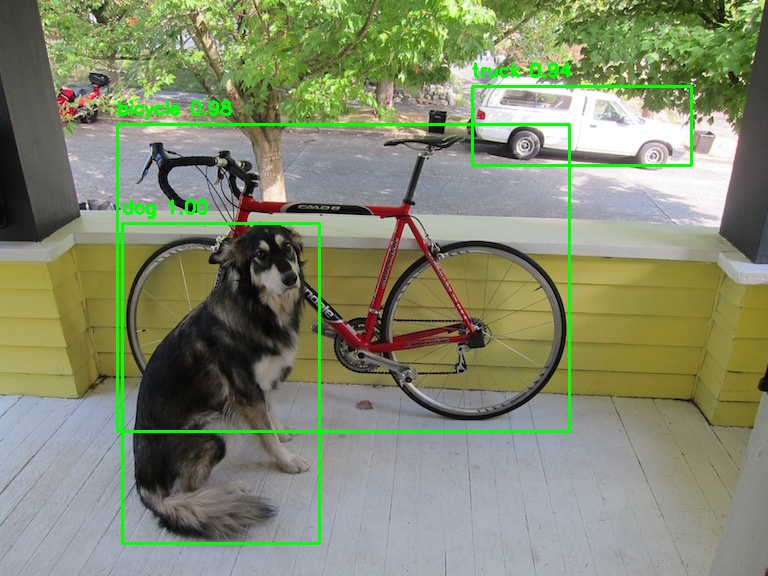

In [6]:
from IPython.display import Image
Image(str(darknet_dir / 'predictions.jpg'))